# Expected Value Calculation on IQM

In [ ]:
from py4lexis.session import LexisSession
from qaas.client import QProvider, QBackend, QJob


# 1. Authentication
lexis_session = LexisSession()
token = lexis_session.get_access_token()

# 2. Configure resources
PROJECT = ""   # e.g. OPEN-37-1
RESOURCE = "" # e.g. VLQ-CZ

# 3. Initialize QaaS
provider = QProvider(token, PROJECT)
backend:QBackend = provider.get_backend(RESOURCE)


Welcome to the Py4LEXIS (v7.0.3)!
Proceeding login via login page...
Open provided url in your browser, please: https:/aai.lexis.tech/auth/realms/LEXIS_AAI_v2/protocol/openid-connect/auth/device?user_code=AQGB-MYUJ
Check if user is logged in: Pending.                                            
Check if user is logged in: OK!
You have been successfully logged in LEXIS session.


# Create the encoding circuit

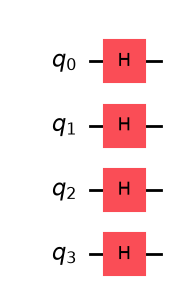

In [123]:
from qiskit import QuantumCircuit
import numpy as np 

qc = QuantumCircuit(4)
qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)

qc.draw('mpl')

# Transpile the circuit with VLQ

In [ ]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.primitives import BackendEstimatorV2


# Pauli string
pauli_strings = ['IIIX','IIXI','IXII','XIII', 'IIIZ','IIZI','IZII','ZIII','IIIY','IIYI','IYII','YIII']
hamiltonian = [SparsePauliOp(ps) for ps  in pauli_strings]

# transpile the circuit and observables
pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
qc_transpiled = pm.run(qc)
obs_transpiled = [h.apply_layout(qc_transpiled.layout) for h in hamiltonian]

[array(0.9384), array(0.896), array(0.0704), array(-0.0136), array(0.9544), array(0.9568), array(0.0232), array(-0.0216), array(0.0248), array(0.02), array(0.0128), array(-0.0104)]


# Create the estimator 

In [ ]:
# start the estimator
estimator = BackendEstimatorV2(backend=backend)

# Batch calculation of the expectation values on VLQ

In [ ]:
# calculate [ <psi(theta)|hamiltonian|psi(theta)> ]
pubs = [(qc_transpiled, h) for h in obs_transpiled]
job = estimator.run(pubs, precision=0.02)
ev_batch = []
for pub_result in job.result():
    ev_batch.append(pub_result.data.evs)
print(ev_batch)

# Sequential calculation of the expectation values on VLQ

In [129]:
# calculate [ <psi(theta)|hamiltonian|psi(theta)> ]
ev_squential = []
for h in obs_transpiled:
    job = estimator.run([(qc_transpiled, h)], precision=0.02)
    pub_result = job.result()
    ev_squential.append(pub_result[0].data.evs)
print(ev_squential)

[array(0.9456), array(0.8936), array(0.964), array(0.952), array(0.0384), array(0.0184), array(0.0688), array(0.), array(0.052), array(0.0256), array(0.0096), array(-0.0088)]


# Exact calculation of the expectation values

In [130]:
from qiskit.primitives import StatevectorEstimator as Estimator

exact_estimator = Estimator()
job_exact = exact_estimator.run([(qc, hamiltonian)])
ev_exact = []
for pub_result in job_exact.result():
    ev_exact.append(pub_result.data.evs)
print(ev_exact)

[array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.77555756e-17,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])]


# Compare exact with batch/sequential VLQ values

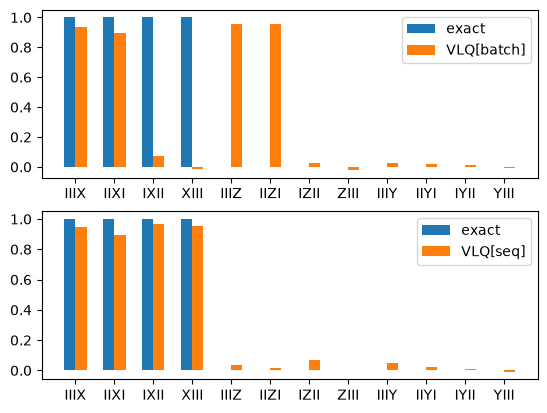

In [134]:
import matplotlib.pyplot as plt

plt.subplot(211)
plt.grouped_bar({'exact':ev_exact[0], 'VLQ[batch]':ev_batch}, tick_labels=pauli_strings)
plt.legend()

plt.subplot(212)
plt.grouped_bar({'exact':ev_exact[0], 'VLQ[seq]':ev_squential}, tick_labels=pauli_strings)
plt.legend()


# Estimate expectation values on VLQ using `transpile_to_IQM`

In [106]:
# from iqm.qiskit_iqm import  transpile_to_IQM

# # Transpile circuit
# qc_iqm_transpiled = transpile_to_IQM(qc, backend, optimize_single_qubits=False)
# qc_iqm_transpiled.draw(output="mpl", idle_wires=False)

# iqm_observables = [h.apply_layout(qc_iqm_transpiled.layout) for h in hamiltonian]

# estimator = BackendEstimatorV2(backend=backend)

# # calculate [ <psi(theta)|hamiltonian|psi(theta)> ]
# pubs = [(isa_qc, h) for h in iqm_observables]
# job = estimator.run(pubs, precision=0.02)
# ev_iqm = []
# for pub_result in job.result():
#     ev_iqm.append(pub_result.data.evs)
# print(ev_iqm)

# Plot VLQ [`transpile_to_iqm`] vs Exact

In [107]:
# import matplotlib.pyplot as plt
# plt.grouped_bar({'exact':ev_exact[0], 'VLQ':ev_iqm}, tick_labels=pauli_strings)
# plt.legend()

# Compare the two VLQ results

In [108]:
# import matplotlib.pyplot as plt
# plt.grouped_bar({'VLQ2':ev_iqm, 'VLQ':ev}, tick_labels=pauli_strings)
# plt.legend()